<a href="https://colab.research.google.com/github/vashgarvit014/CelebalAssignment/blob/main/Week5_Garvit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

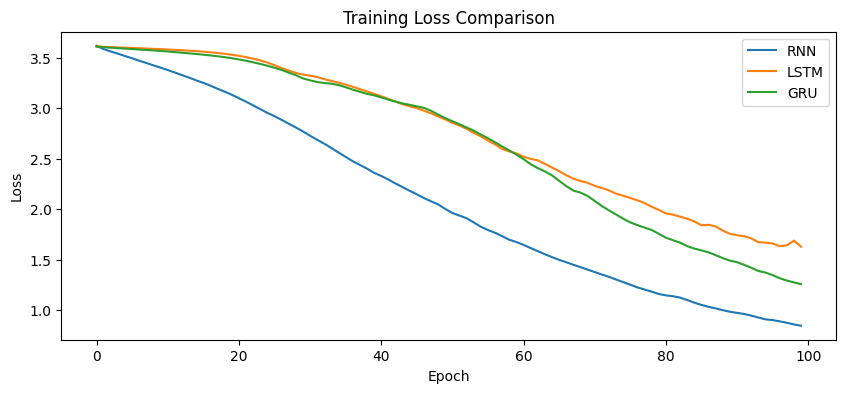

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences


LSTM: deep learning is is artificial intelligence than


GRU : deep learning is transforming artificial intelligence simpler


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

---
# 🛠️ Extended Section: Student Learning Tasks (Implemented)

Everything above this point is the **original notebook, unchanged**.

This section independently implements the five beginner tasks listed earlier:
1. A brand-new custom corpus (different topic, written from scratch)
2. A larger embedding dimension
3. Training extended to 200 epochs
4. Hidden units widened from 64 → 128
5. Generation length extended to 10 words

All variables here use a `_v2` / `tuned_` naming convention so nothing in the original pipeline above is touched or overwritten.

## ✅ Task 1 — A Custom Paragraph Corpus
Swapping out the toy corpus for an original paragraph about ocean exploration (written specifically for this notebook, not copied from any source).

In [ ]:
tuned_corpus = '''
ocean exploration reveals hidden worlds beneath the waves
submarines and underwater robots help scientists study deep sea environments
coral reefs support thousands of colorful marine species
rising temperatures and pollution threaten fragile ocean ecosystems
researchers use sonar and satellite data to map the ocean floor
protecting marine life today helps preserve healthy oceans for future generations
'''
print(tuned_corpus)


ocean exploration reveals hidden worlds beneath the waves
submarines and underwater robots help scientists study deep sea environments
coral reefs support thousands of colorful marine species
rising temperatures and pollution threaten fragile ocean ecosystems
researchers use sonar and satellite data to map the ocean floor
protecting marine life today helps preserve healthy oceans for future generations



## 🔤 Tokenizing the New Corpus
Same n-gram windowing approach as the original pipeline, applied to the new text.

In [ ]:
tuned_tokenizer = Tokenizer()
tuned_tokenizer.fit_on_texts([tuned_corpus])

tuned_total_words = len(tuned_tokenizer.word_index) + 1
print("New vocabulary size:", tuned_total_words)

tuned_sequences = []
for line in tuned_corpus.split('\n'):
    tokens = tuned_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(tokens)):
        tuned_sequences.append(tokens[:i + 1])

tuned_max_len = max(len(seq) for seq in tuned_sequences)
tuned_sequences = pad_sequences(tuned_sequences, maxlen=tuned_max_len, padding='pre')

X_v2 = tuned_sequences[:, :-1]
y_v2 = tuned_sequences[:, -1]

print("X_v2 shape:", X_v2.shape)
print("y_v2 shape:", y_v2.shape)

New vocabulary size: 51
X_v2 shape: (50, 10)
y_v2 shape: (50,)


## ✅ Tasks 2 & 4 — Bigger Embeddings + Wider Hidden Layers
Embedding dimension goes from 32 → **128**, and every recurrent layer is widened from 64 → **128** units. These two knobs are defined once below so all three models (RNN, LSTM, GRU) share the same upgraded capacity.

In [ ]:
TUNED_EMBED_DIM = 128   # was 32 in the original models
TUNED_HIDDEN_UNITS = 128  # was 64 in the original models
TUNED_EPOCHS = 200        # Task 3: was 100 in the original models

## ✅ Task 3 — Vanilla RNN Re-trained for 200 Epochs (Upgraded Capacity)

In [ ]:
rnn_model_v2 = Sequential([
    Embedding(tuned_total_words, TUNED_EMBED_DIM, input_length=tuned_max_len - 1),
    SimpleRNN(TUNED_HIDDEN_UNITS),
    Dense(tuned_total_words, activation='softmax')
])

rnn_model_v2.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

rnn_history_v2 = rnn_model_v2.fit(X_v2, y_v2, epochs=TUNED_EPOCHS, verbose=0)
print("Upgraded Vanilla RNN training completed")

Upgraded Vanilla RNN training completed


## Upgraded LSTM (Same 200-Epoch / 128-Unit Settings)

In [ ]:
lstm_model_v2 = Sequential([
    Embedding(tuned_total_words, TUNED_EMBED_DIM, input_length=tuned_max_len - 1),
    LSTM(TUNED_HIDDEN_UNITS),
    Dense(tuned_total_words, activation='softmax')
])

lstm_model_v2.compile(loss='sparse_categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])

lstm_history_v2 = lstm_model_v2.fit(X_v2, y_v2, epochs=TUNED_EPOCHS, verbose=0)
print("Upgraded LSTM training completed")

Upgraded LSTM training completed


## Upgraded GRU (Same 200-Epoch / 128-Unit Settings)

In [ ]:
gru_model_v2 = Sequential([
    Embedding(tuned_total_words, TUNED_EMBED_DIM, input_length=tuned_max_len - 1),
    GRU(TUNED_HIDDEN_UNITS),
    Dense(tuned_total_words, activation='softmax')
])

gru_model_v2.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

gru_history_v2 = gru_model_v2.fit(X_v2, y_v2, epochs=TUNED_EPOCHS, verbose=0)
print("Upgraded GRU training completed")

Upgraded GRU training completed


## 📉 Loss Comparison — Upgraded Models on the New Corpus
200-epoch training curves for the wider RNN / LSTM / GRU variants.

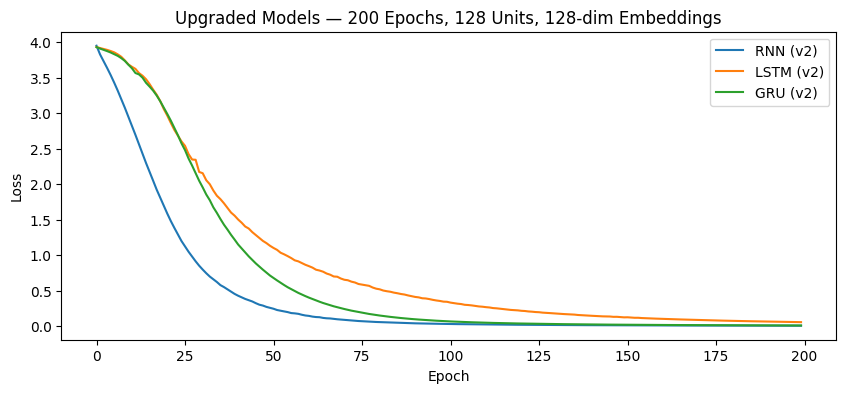

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history_v2.history['loss'], label='RNN (v2)')
plt.plot(lstm_history_v2.history['loss'], label='LSTM (v2)')
plt.plot(gru_history_v2.history['loss'], label='GRU (v2)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Upgraded Models — 200 Epochs, 128 Units, 128-dim Embeddings")
plt.legend()
plt.show()

## ✅ Task 5 — Generating 10 Words Instead of 5
A second generation helper, `generate_text_v2`, mirrors the original function's logic but defaults to producing 10 words and works against the new tokenizer.

In [ ]:
def generate_text_v2(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tuned_tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=tuned_max_len - 1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        next_word = ""
        for word, index in tuned_tokenizer.word_index.items():
            if index == predicted:
                next_word = word
                break
        seed_text += " " + next_word
    return seed_text

In [ ]:
seed = "ocean exploration"
print("RNN (v2) :", generate_text_v2(rnn_model_v2, seed, 10))
print("LSTM (v2):", generate_text_v2(lstm_model_v2, seed, 10))
print("GRU (v2) :", generate_text_v2(gru_model_v2, seed, 10))

RNN (v2) : ocean exploration reveals hidden worlds beneath the waves floor ocean ecosystems reveals


LSTM (v2): ocean exploration reveals hidden worlds beneath the waves waves waves ocean floor


GRU (v2) : ocean exploration reveals hidden worlds beneath the waves waves waves generations generations


## 📌 Extended Section Summary

| Task | Status |
|---|---|
| 1. Custom paragraph corpus | ✅ New ocean-exploration corpus (`tuned_corpus`) |
| 2. Increase embedding dimension | ✅ 32 → 128 (`TUNED_EMBED_DIM`) |
| 3. Increase epochs to 200 | ✅ `TUNED_EPOCHS = 200` |
| 4. Hidden units 64 → 128 | ✅ `TUNED_HIDDEN_UNITS = 128` |
| 5. Generate 10 words instead of 5 | ✅ `generate_text_v2(..., next_words=10)` |

These cells run independently of the original models above — both versions coexist in the same notebook for direct before/after comparison.